# GOES GLM lightning over True Color

The Geostationary Lightning Mapper reports individual optical **flashes** with
a latitude, longitude and time. Here they go on top of a True Color image.

The example is a line of afternoon thunderstorms over the central United States
on 3 October 2023 around 20:00 UTC, about 14:00 local, so there is daylight for
True Color. GOES-16 sees that region.

Download the files first with the
[GOES & JPSS Data Downloader](https://rmsm95.github.io/GOES-NESDIS_downlaoder/),
then point `DATA_DIR` at the folder they landed in. Nothing is downloaded here.

**Steps:** your files -> the whole scan -> your box -> that box.

The plotting is plain matplotlib and cartopy, written out where it happens, so
change the colours, the projection or anything else right there.

## Setup

In [1]:
import glob
import sys
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import yaml

sys.path.insert(0, "..")
import goestools as gt

CONFIG = yaml.safe_load(open("../config.yml"))
STYLE = CONFIG["style"]          # colours, widths, figure size


## 1. Your files

Two products for the same moment: the ABI channels for True Color, and the GLM
flash files.

In [2]:
ABI_DIR = Path("..") / CONFIG["data"]["glm_abi"]
GLM_DIR = Path("..") / CONFIG["data"]["glm_flashes"]

abi_files = sorted(glob.glob(str(ABI_DIR / "*.nc")))
glm_files = sorted(glob.glob(str(GLM_DIR / "*.nc")))
print(f"ABI: {len(abi_files)} file(s)")
print(f"GLM: {len(glm_files)} file(s)")

paths = gt.find_channels(abi_files, ["C01", "C02", "C03"])


ABI: 3 file(s)
GLM: 30 file(s)


## 2. Your box

GLM watches the whole disk, so this box decides which flashes are drawn as well
as the extent of the image.

In [3]:
BOX = (-104.0, -97.0, 36.0, 43.0)

flash_lon, flash_lat = gt.read_glm_flashes(glm_files, BOX)
print(f"{len(flash_lon)} flashes inside the box")


1056 flashes inside the box


## 3. True Color with the flashes on top

Every flash in the files you downloaded is drawn, so the length of that
download sets how much of the storm's history shows in one frame.

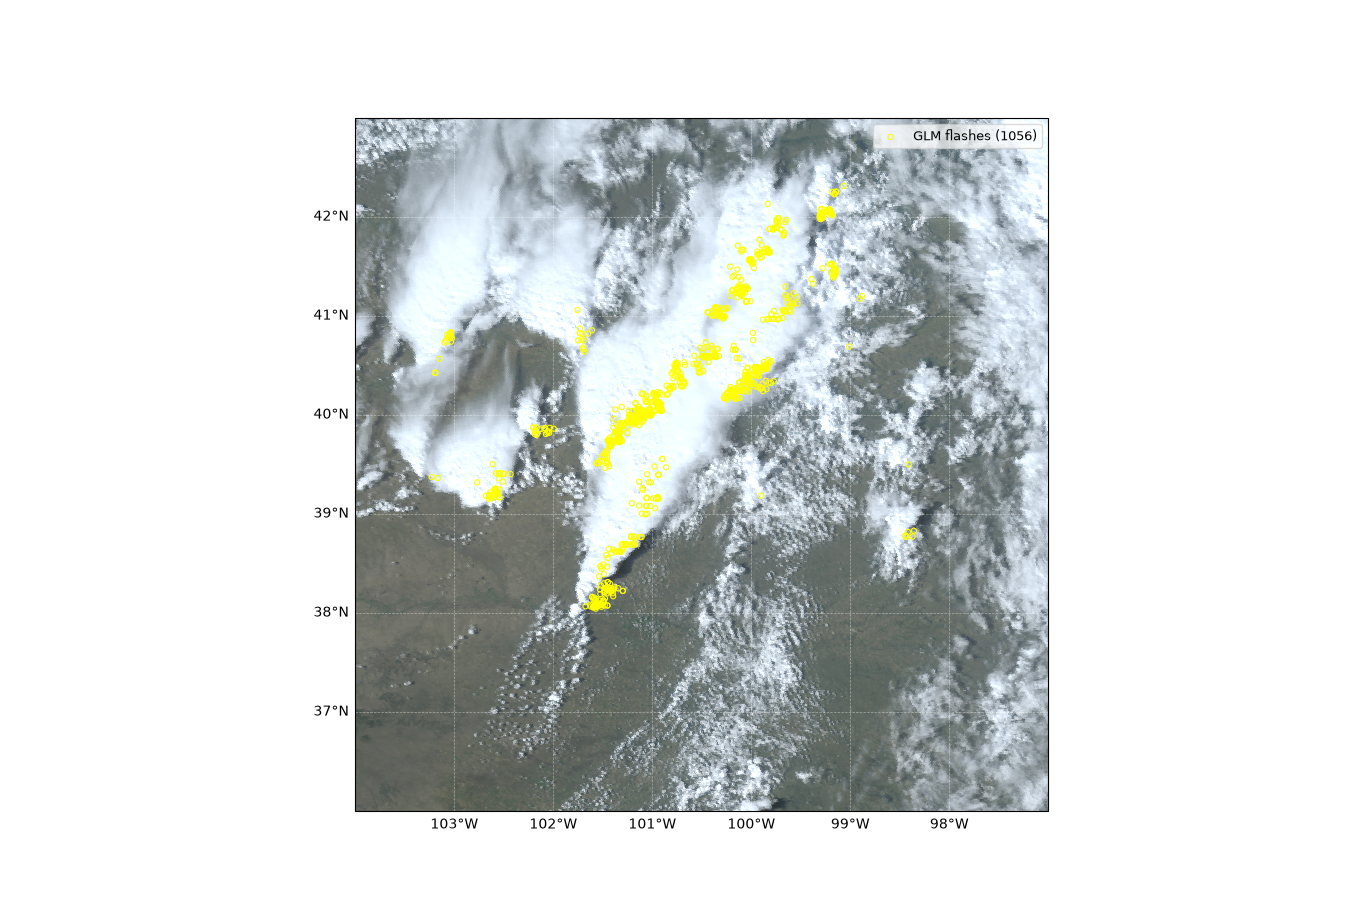

In [4]:
rgb = gt.true_color(abi_files, *BOX)

fig = plt.figure(figsize=(STYLE["figure_width"], 9))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

gt.draw_rgb(ax, rgb, transform=ccrs.PlateCarree())

ax.scatter(flash_lon, flash_lat, s=STYLE["flash_size"], marker="o",
           facecolors="none", edgecolors=STYLE["flash_colour"],
           linewidths=STYLE["flash_edge_width"], transform=ccrs.PlateCarree(),
           zorder=5, label=f"GLM flashes ({len(flash_lon)})")
ax.legend(loc="upper right", framealpha=0.7, fontsize=9)

ax.coastlines(resolution=STYLE["coast_resolution"],
              color=STYLE["coast_colour"], linewidth=STYLE["coast_width"])
grid = ax.gridlines(draw_labels=True, color=STYLE["grid_colour"],
                    alpha=STYLE["grid_alpha"], linestyle=STYLE["grid_style"],
                    linewidth=STYLE["grid_width"])
grid.top_labels = grid.right_labels = False

ax.set_extent(BOX, crs=ccrs.PlateCarree())
ax.set_title("G16 - True Color + GLM flashes", loc="left")
ax.set_title(f"{rgb.time:%Y/%m/%d %H:%M} UTC", loc="right")
plt.show()


## Notes

* GLM sees the flash at **cloud top**, so the circles sit over the anvil rather
  than at the ground strike point. That they land on the bright convective tops
  is the check that the geolocation lines up.
* Detection efficiency falls towards the edge of the disk and at high latitude,
  which matters for volcanic lightning at Alaskan latitudes.